# Pneumonia Classification from Chest X-rays

**Computer Vision Assignment 2

Goal: Improve a baseline CNN to maximise accuracy, precision, and recall when classifying chest X-ray images as NORMAL or PNEUMONIA.

Dataset: Chest X-ray images train/test split provided

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check GPU availability
import tensorflow as tf
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: []


In [3]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Rescaling
from tensorflow.keras.optimizers import Adam

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
# Dataset paths - UPDATE THESE to match your Google Drive structure
TRAIN_DIR = '/content/drive/MyDrive/Colab Notebooks/chest_xray/train'
TEST_DIR  = '/content/drive/MyDrive/Colab Notebooks/chest_xray/test'
# Hyperparameters (from lecturer's baseline script)
BATCH_SIZE = 12
EPOCHS = 8
IMG_HEIGHT = 128
IMG_WIDTH  = 128
IMG_CHANNELS = 3

In [5]:
# Load training data with 80/20 train/val split
train_ds, val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    seed=123,
    validation_split=0.2,
    subset='both',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=True
)

# Load test data
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    seed=None,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    labels='inferred',
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Class names:', class_names)
print('Number of classes:', num_classes)

Found 5419 files belonging to 3 classes.
Using 4336 files for training.
Using 1083 files for validation.
Found 437 files belonging to 3 classes.
Class names: ['BACTERIAL', 'NORMAL', 'VIRAL']
Number of classes: 3


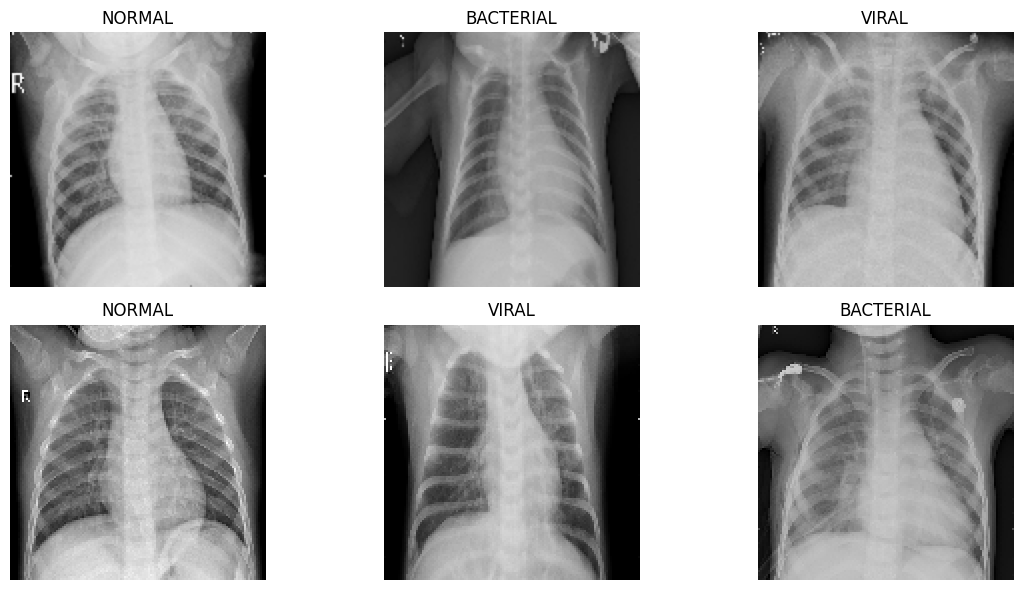

In [6]:
# Display a few sample images from the training set
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i].numpy()])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [7]:
# Build the baseline CNN
model = Sequential([
    Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    Conv2D(16, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,227,651 (12.31 MB)

 Trainable params: 3,227,651 (12.31 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train and measure training time
start_time = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

training_time = time.time() - start_time
print(f'\nTraining completed in {training_time:.1f} seconds ({training_time/60:.1f} minutes)')

Epoch 1/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 569s 2s/step - accuracy: 0.7096 - loss: 0.6744 - val_accuracy: 0.7719 - val_loss: 0.5354
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 123s 340ms/step - accuracy: 0.7848 - loss: 0.5175 - val_accuracy: 0.7719 - val_loss: 0.5365
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 141s 339ms/step - accuracy: 0.8019 - loss: 0.4659 - val_accuracy: 0.7747 - val_loss: 0.5279
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 128s 352ms/step - accuracy: 0.8173 - loss: 0.4297 - val_accuracy: 0.7655 - val_loss: 0.5364
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 139s 345ms/step - accuracy: 0.8339 - loss: 0.3913 - val_accuracy: 0.7849 - val_loss: 0.5341
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 125s 346ms/step - accuracy: 0.8446 - loss: 0.3448 - val_accuracy: 0.7664 - val_loss: 0.6157
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 131s 362ms/step - accuracy: 0.8764 - loss: 0.2979 - val_accuracy: 0.7627 - val_loss: 0.6294
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 123s 341ms/step - accuracy: 0.9018 - loss: 0.23

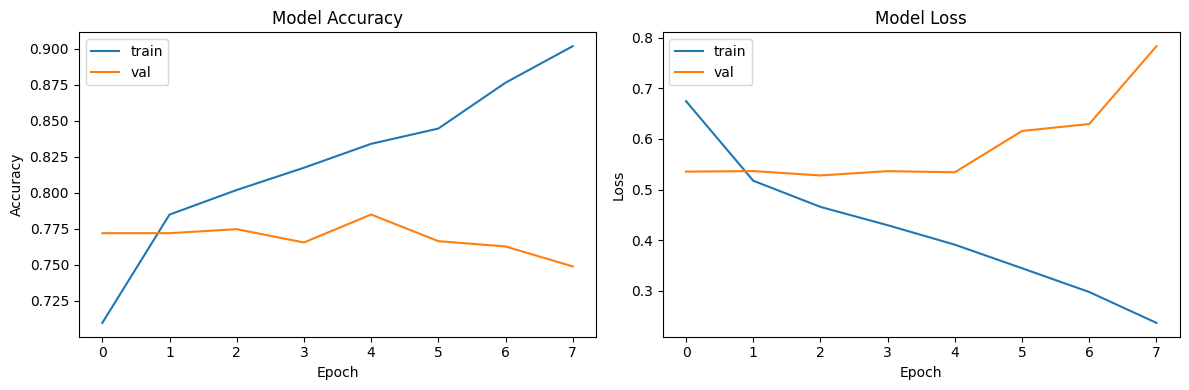

In [9]:
# Plot accuracy and loss curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Collect all predictions and true labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [11]:
# Overall test accuracy
test_accuracy = (y_true == y_pred).mean()
print(f'Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')
print()

Test Accuracy: 0.7712 (77.12%)



In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Per-class precision, recall, F1
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

Classification Report:
              precision    recall  f1-score   support

   BACTERIAL     0.7183    0.8315    0.7708       184
      NORMAL     0.8898    0.9262    0.9076       122
       VIRAL     0.7320    0.5420    0.6228       131

    accuracy                         0.7712       437
   macro avg     0.7800    0.7666    0.7671       437
weighted avg     0.7703    0.7712    0.7646       437



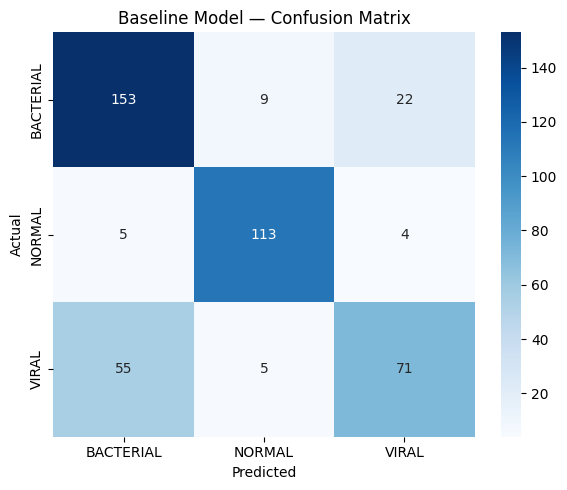

In [13]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Baseline Model — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

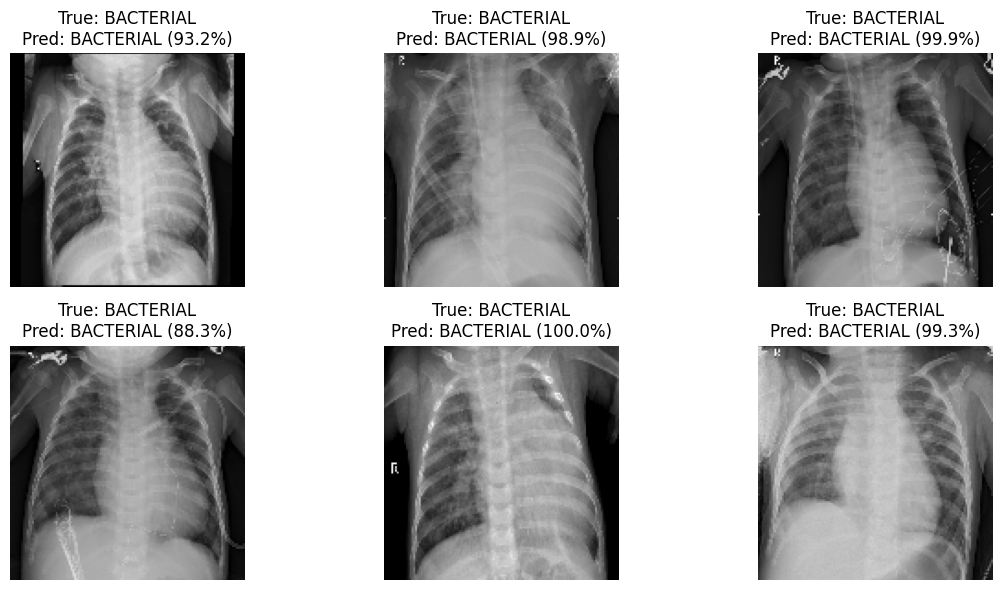

In [14]:
# Show predictions on a few test images
test_batch = test_ds.take(1)
plt.figure(figsize=(12, 6))
for images, labels in test_batch:
    for i in range(6):
        ax = plt.subplot(2, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))

        # Make prediction
        prediction = model.predict(tf.expand_dims(images[i], 0), verbose=0)
        pred_class = class_names[np.argmax(prediction)]
        true_class = class_names[labels[i].numpy()]
        confidence = 100 * np.max(prediction)

        plt.title(f'True: {true_class}\nPred: {pred_class} ({confidence:.1f}%)')
        plt.axis('off')
plt.tight_layout()
plt.show()

In [15]:
# ============================================
# EXPERIMENT 1: Data Augmentation
# ============================================
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

model_aug = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_aug.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

print("Training model WITH data augmentation...")
history_aug = model_aug.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# Evaluate
y_true_aug = []
y_pred_aug = []
for images, labels in test_ds:
    preds = model_aug.predict(images, verbose=0)
    y_true_aug.extend(labels.numpy())
    y_pred_aug.extend(np.argmax(preds, axis=1))

y_true_aug = np.array(y_true_aug)
y_pred_aug = np.array(y_pred_aug)

aug_accuracy = (y_true_aug == y_pred_aug).mean()
print(f'\nAugmented Model Accuracy: {aug_accuracy:.4f} ({aug_accuracy*100:.2f}%)')
print(classification_report(y_true_aug, y_pred_aug,
      target_names=class_names, digits=4))

Training model WITH data augmentation...
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


362/362 ━━━━━━━━━━━━━━━━━━━━ 154s 412ms/step - accuracy: 0.5830 - loss: 0.8915 - val_accuracy: 0.6842 - val_loss: 0.6787
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 194s 393ms/step - accuracy: 0.6937 - loss: 0.6946 - val_accuracy: 0.6990 - val_loss: 0.6262
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 142s 390ms/step - accuracy: 0.7283 - loss: 0.6454 - val_accuracy: 0.7258 - val_loss: 0.6086
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 153s 421ms/step - accuracy: 0.7401 - loss: 0.6056 - val_accuracy: 0.7331 - val_loss: 0.6204
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 191s 391ms/step - accuracy: 0.7523 - loss: 0.5950 - val_accuracy: 0.7608 - val_loss: 0.5803
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 146s 402ms/step - accuracy: 0.7636 - loss: 0.5779 - val_accuracy: 0.7368 - val_loss: 0.5887
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 142s 392ms/step - accuracy: 0.7678 - loss: 0.5645 - val_accuracy: 0.7812 - val_loss: 0.5434
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 206s 403ms/step - accuracy: 0.7638 - loss: 0.5637 - va

Data augmentation was applied to the  reduce overfitting. Random horizontal flips rotations, zooms and contrast adjustments were added as a first layers of the model. The results are mixed - NORMAL recall improved from 87% to 95% and BACTERIAL from 86% to 90%, but VIRAL recall dropped from 53% to 28%. Overall accuracy fell slightly from 76.89% to 73.23%.

In [16]:
# ============================================
# EXPERIMENT 2: Class Weighting
# ============================================
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to fix VIRAL recall problem
all_labels = []
for images, labels in train_ds:
    all_labels.extend(labels.numpy())
all_labels = np.array(all_labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(all_labels),
    y=all_labels
)
class_weight_dict = dict(enumerate(class_weights))
print('Class weights:', class_weight_dict)

# Same model as experiment 1 but with class weights
model_weighted = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(16, (3,3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_weighted.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(),
    metrics=['accuracy']
)

print("Training WITH class weights...")
history_weighted = model_weighted.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict
)

# Evaluate
y_true_w = []
y_pred_w = []
for images, labels in test_ds:
    preds = model_weighted.predict(images, verbose=0)
    y_true_w.extend(labels.numpy())
    y_pred_w.extend(np.argmax(preds, axis=1))

y_true_w = np.array(y_true_w)
y_pred_w = np.array(y_pred_w)

w_accuracy = (y_true_w == y_pred_w).mean()
print(f'\nWeighted Model Accuracy: {w_accuracy:.4f} ({w_accuracy*100:.2f}%)')
print(classification_report(y_true_w, y_pred_w,
      target_names=class_names, digits=4))

Class weights: {0: np.float64(0.6925411276153969), 1: np.float64(1.240629470672389), 2: np.float64(1.3333333333333333)}
Training WITH class weights...
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


362/362 ━━━━━━━━━━━━━━━━━━━━ 146s 397ms/step - accuracy: 0.5445 - loss: 0.9106 - val_accuracy: 0.7101 - val_loss: 0.7264
Epoch 2/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 145s 400ms/step - accuracy: 0.6840 - loss: 0.7094 - val_accuracy: 0.7165 - val_loss: 0.6445
Epoch 3/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 139s 384ms/step - accuracy: 0.7000 - loss: 0.6743 - val_accuracy: 0.7341 - val_loss: 0.6278
Epoch 4/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 147s 402ms/step - accuracy: 0.7221 - loss: 0.6315 - val_accuracy: 0.7405 - val_loss: 0.6059
Epoch 5/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 136s 374ms/step - accuracy: 0.7249 - loss: 0.6233 - val_accuracy: 0.7368 - val_loss: 0.6264
Epoch 6/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 142s 390ms/step - accuracy: 0.7366 - loss: 0.5984 - val_accuracy: 0.7267 - val_loss: 0.5957
Epoch 7/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 145s 400ms/step - accuracy: 0.7438 - loss: 0.5885 - val_accuracy: 0.7525 - val_loss: 0.5657
Epoch 8/8
362/362 ━━━━━━━━━━━━━━━━━━━━ 143s 396ms/step - accuracy: 0.7463 - loss: 0.5689 - va

Class weighting improved NORMAL recall to 98% and recovered VIRAL recall to 52%. The model is more balanced but VIRAL recall still needs improvement

In [17]:
# ============================================
# EXPERIMENT 3: Improved Architecture
# ============================================

from tensorflow.keras.layers import GlobalAveragePooling2D, BatchNormalization

model_improved = tf.keras.models.Sequential([
    data_augmentation,
    Rescaling(1.0/255),
    Conv2D(32, (3, 3), activation='relu',
           input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),  # replaces the Flatten - fewer params, less overfitting
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model_improved.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_improved.summary()

# EarlyStopping stops training when val_loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_improved = model_improved.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # more epochs but early stopping will kick in
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

# Evaluate
y_true_i = []
y_pred_i = []
for images, labels in test_ds:
    preds = model_improved.predict(images, verbose=0)
    y_true_i.extend(labels.numpy())
    y_pred_i.extend(np.argmax(preds, axis=1))

y_true_i = np.array(y_true_i)
y_pred_i = np.array(y_pred_i)

print(f'Improved Model Accuracy: {(y_true_i == y_pred_i).mean():.4f}')
print(classification_report(y_true_i, y_pred_i,
      target_names=class_names, digits=4))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,939 (499.76 KB)

 Trainable params: 127,491 (498.01 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 263s 715ms/step - accuracy: 0.5929 - loss: 0.8606 - val_accuracy: 0.4026 - val_loss: 2.4211
Epoch 2/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 264s 719ms/step - accuracy: 0.6381 - loss: 0.7820 - val_accuracy: 0.6020 - val_loss: 0.8930
Epoch 3/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 254s 699ms/step - accuracy: 0.6649 - loss: 0.7496 - val_accuracy: 0.4903 - val_loss: 1.1901
Epoch 4/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 253s 699ms/step - accuracy: 0.6762 - loss: 0.7278 - val_accuracy: 0.4968 - val_loss: 1.2488
Epoch 5/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 257s 709ms/step - accuracy: 0.6870 - loss: 0.6900 - val_accuracy: 0.6667 - val_loss: 0.6972
Epoch 6/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 251s 694ms/step - accuracy: 0.6923 - loss: 0.6702 - val_accuracy: 0.6741 - val_loss: 0.7079
Epoch 7/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 252s 694ms/step - accuracy: 0.6919 - loss: 0.6730 - val_accuracy: 0.4460 - val_loss: 1.4942
Epoch 8/20
362/362 ━━━━━━━━━━━━━━━━━━━━ 250s 690ms/step - accuracy: 0.7113 -

The improved architecture with GlobalAveragePooling2D performed worse on its own 64.53% showsthe model needs pretrained weights to learn effectively with this architecture

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training with MobileNetV2 transfer learning...
Epoch 1/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 140s 362ms/step - accuracy: 0.6571 - loss: 0.7305 - val_accuracy: 0.6565 - val_loss: 0.8387
Epoch 2/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 127s 350ms/step - accuracy: 0.7108 - loss: 0.6216 - val_accuracy: 0.6630 - val_loss: 0.7591
Epoch 3/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 132s 364ms/step - accuracy: 0.7315 - loss: 0.6001 - val_accuracy: 0.6030 - val_loss: 0.9689
Epoch 4/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 129s 357ms/step - accuracy: 0.7373 - loss: 0.5948 - val_accuracy: 0.6408 - val_loss: 0.7218
Epoch 5/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 147s 407ms/step - accuracy: 0.7403 - loss: 0.5746 - val_accuracy: 0.7285 - val_loss: 0.6930
Epoch 6/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 149s 411ms/step - accuracy: 0.7509 - loss: 0.5665 - val_accuracy: 0.7331 - val_loss: 0.7091
Epoch 7/15
362/362 ━━━━━━━━━━━━━━━━━━━━ 148s 409ms/step - accuracy: 0.7571 - loss: 0.5498 - val_accuracy: 0.6500 - val_loss: 0.7197
Epoch 8/15
362/362 ━━━━━━━━━━

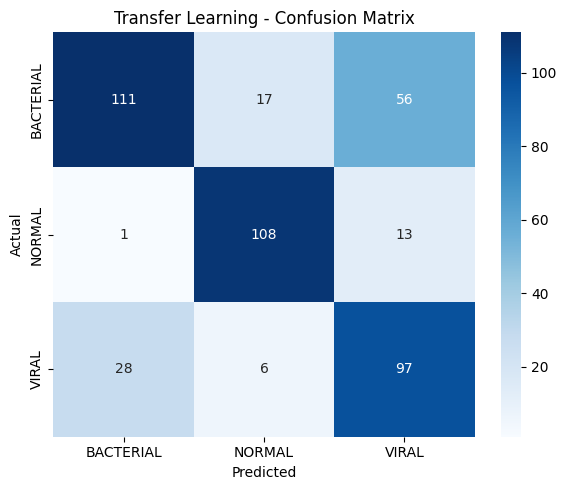

In [18]:
# ============================================
# EXPERIMENT 4: Transfer Learning with MobileNetV2
# ============================================

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model - we only train our own head
base_model.trainable = False

# Build the transfer learning model
model_transfer = tf.keras.models.Sequential([
    data_augmentation,
    tf.keras.layers.Lambda(preprocess_input),  # MobileNetV2's own preprocessing
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

model_transfer.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model_transfer.summary()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

print("Training with MobileNetV2 transfer learning...")
start_time = time.time()
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
transfer_time = time.time() - start_time
print(f'Training time: {transfer_time/60:.1f} minutes')

# Evaluate
y_true_t = []
y_pred_t = []
for images, labels in test_ds:
    preds = model_transfer.predict(images, verbose=0)
    y_true_t.extend(labels.numpy())
    y_pred_t.extend(np.argmax(preds, axis=1))

y_true_t = np.array(y_true_t)
y_pred_t = np.array(y_pred_t)

t_accuracy = (y_true_t == y_pred_t).mean()
print(f'\nTransfer Learning Accuracy: {t_accuracy:.4f} ({t_accuracy*100:.2f}%)')
print(classification_report(y_true_t, y_pred_t,
      target_names=class_names, digits=4))

# Confusion matrix
cm_t = confusion_matrix(y_true_t, y_pred_t)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_t, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Transfer Learning - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [19]:
# ============================================
# EXPERIMENT 5: Fine-tuning MobileNetV2
# ============================================

# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"Total layers: {len(base_model.layers)}")
print(f"Trainable layers: 30 (last 30 layers)")

# Recompile with very low learning rate (10x lower)
model_transfer.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0001),  # much lower LR
    metrics=['accuracy']
)

print("Fine-tuning MobileNetV2...")
start_time = time.time()
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)
finetune_time = time.time() - start_time
print(f'Fine-tuning time: {finetune_time/60:.1f} minutes')

# Evaluate
y_true_f = []
y_pred_f = []
for images, labels in test_ds:
    preds = model_transfer.predict(images, verbose=0)
    y_true_f.extend(labels.numpy())
    y_pred_f.extend(np.argmax(preds, axis=1))

y_true_f = np.array(y_true_f)
y_pred_f = np.array(y_pred_f)

f_accuracy = (y_true_f == y_pred_f).mean()
print(f'\nFine-tuned Model Accuracy: {f_accuracy:.4f} ({f_accuracy*100:.2f}%)')
print(classification_report(y_true_f, y_pred_f,
      target_names=class_names, digits=4))

Total layers: 154
Trainable layers: 30 (last 30 layers)
Fine-tuning MobileNetV2...
Epoch 1/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 197s 504ms/step - accuracy: 0.7189 - loss: 0.6568 - val_accuracy: 0.7470 - val_loss: 0.6095
Epoch 2/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 177s 488ms/step - accuracy: 0.7495 - loss: 0.5823 - val_accuracy: 0.7775 - val_loss: 0.5233
Epoch 3/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 157s 432ms/step - accuracy: 0.7754 - loss: 0.5251 - val_accuracy: 0.7295 - val_loss: 0.7063
Epoch 4/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 160s 441ms/step - accuracy: 0.7733 - loss: 0.5076 - val_accuracy: 0.7138 - val_loss: 0.7299
Epoch 5/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 180s 496ms/step - accuracy: 0.7844 - loss: 0.4912 - val_accuracy: 0.6971 - val_loss: 0.7217
Epoch 6/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 161s 444ms/step - accuracy: 0.7904 - loss: 0.4695 - val_accuracy: 0.6722 - val_loss: 0.9478
Epoch 7/10
362/362 ━━━━━━━━━━━━━━━━━━━━ 178s 490ms/step - accuracy: 0.7878 - loss: 0.4653 - val_accuracy: 0.6907 - val_loss: 

In [20]:
# ============================================
# EXPERIMENT 6: Hyperparameter Tuning with KerasTuner
# ============================================


!pip install -q keras-tuner

import keras_tuner as kt

def build_tuned_model(hp):
    # Hyperparameters to search
    hp_units = hp.Choice('units', values=[64, 128, 256])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    hp_dropout = hp.Choice('dropout', values=[0.2, 0.3, 0.5])

    base = MobileNetV2(
        input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    model = tf.keras.models.Sequential([
        data_augmentation,
        tf.keras.layers.Lambda(preprocess_input),
        base,
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(hp_units, activation='relu'),
        tf.keras.layers.Dropout(hp_dropout),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=Adam(learning_rate=hp_learning_rate),
        metrics=['accuracy']
    )
    return model

# Create the tuner small search to save time
tuner = kt.RandomSearch(
    build_tuned_model,
    objective='val_accuracy',
    max_trials=5,  # only 5 trials to save time
    directory='kt_dir',
    project_name='pneumonia_tuning'
)

print("Searching for best hyperparameters...")
tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weight_dict
)

# Get best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"\nBest hyperparameters found:")
print(f"  Units: {best_hps.get('units')}")
print(f"  Learning rate: {best_hps.get('learning_rate')}")
print(f"  Dropout: {best_hps.get('dropout')}")

Trial 5 Complete [00h 14m 10s]
val_accuracy: 0.698060929775238

Best val_accuracy So Far: 0.7386888265609741
Total elapsed time: 01h 02m 28s

Best hyperparameters found:
  Units: 128
  Learning rate: 0.001
  Dropout: 0.3
